# LDPC Code Tutorial

## Imports and setup

In [15]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]

repo_root = None
for c in candidates:
    if (c / "ldpc" / "__init__.py").exists():
        repo_root = c
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find the repository root. Put this notebook inside the repo, "
        "for example in tutorials/."
    )

repo_root_str = str(repo_root)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

for name in list(sys.modules):
    if name == "ldpc" or name.startswith("ldpc."):
        del sys.modules[name]

importlib.invalidate_caches()

import ldpc
import ldpc.config as config
import ldpc.encoder as encoder
import ldpc.decoder as decoder

print("Repository root:", repo_root)
print("LDPC package:", ldpc.__file__)
print("Encoder module:", encoder.__file__)

Repository root: /Users/vasilandonov/Downloads/turbo-vs-ldpc-analysis
LDPC package: /Users/vasilandonov/Downloads/turbo-vs-ldpc-analysis/ldpc/__init__.py
Encoder module: /Users/vasilandonov/Downloads/turbo-vs-ldpc-analysis/ldpc/encoder.py


## Tutorial parameters

The BER curves later in the notebook are illustrative and smooth for tutorial purposes.  
The worked encoding and decoding example uses the **real repository code**.


In [16]:
TUTORIAL_ITERATIONS = [1, 2, 3]
TUTORIAL_LDPC_EBN0_DB = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
TUTORIAL_RATE_LABEL = "1/3"
SEED = config.RANDOM_SEED

settings_df = pd.DataFrame({
    "Parameter": [
        "Iterations",
        "LDPC Eb/N0 points",
        "Rate label",
        "Seed",
    ],
    "Value": [
        str(TUTORIAL_ITERATIONS),
        str(TUTORIAL_LDPC_EBN0_DB.tolist()),
        TUTORIAL_RATE_LABEL,
        SEED,
    ],
})
settings_df

,Parameter,Value
0,Iterations,"[1, 2, 3]"
1,LDPC Eb/N0 points,"[0.0, 0.5, 1.0, 1.5, 2.0]"
2,Rate label,1/3
3,Seed,12


## Helper functions

These notebook-level helper functions keep the tutorial robust and fast while still using the actual project encoder and decoder.


In [17]:
def tutorial_build_ldpc(rate_label=TUTORIAL_RATE_LABEL):
    H, A, B, codeword_bits, parity_bits = encoder.build_ra_ldpc_matrices(rate_label)
    edge_variable, check_edge_start, variable_edges, variable_edge_start = encoder.build_edge_structure(H)
    information_bits = A.shape[1]
    return {
        "H": H,
        "A": A,
        "B": B,
        "codeword_bits": codeword_bits,
        "parity_bits": parity_bits,
        "information_bits": information_bits,
        "edge_variable": edge_variable,
        "check_edge_start": check_edge_start,
        "variable_edges": variable_edges,
        "variable_edge_start": variable_edge_start,
    }

def tutorial_encode_ldpc(info_bits, A, B):
    info_bits = np.asarray(info_bits, dtype=np.int8)
    if info_bits.shape[0] != A.shape[1]:
        raise ValueError(f"Information length mismatch: got {info_bits.shape[0]}, expected {A.shape[1]}")
    return encoder.encode_ra_ldpc(info_bits, A, B)

def llr_to_bits_ldpc(llr, information_bits):
    return (llr[:information_bits] < 0.0).astype(np.int8)

def plot_ldpc_soft_convergence(history, iterations, n_bits=20):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    x = np.arange(n_bits)
    markers = ["o", "s", "^", "D", "v", "P"]
    for idx, it in enumerate(iterations):
        ax.plot(
            x,
            history[idx, :n_bits],
            marker=markers[idx % len(markers)],
            linewidth=1.8,
            markersize=5,
            label=f"Iteration {it}",
        )
    ax.axhline(0.0, linewidth=1.0, linestyle="--")
    ax.set_xlabel("Bit index")
    ax.set_ylabel("Posterior LLR")
    ax.set_title("LDPC decoder convergence on one block")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(frameon=True)
    fig.tight_layout()
    return fig, ax

def plot_ldpc_ber(ebn0, ldpc_results, iterations):
    fig, ax = plt.subplots(figsize=(8, 4.8))
    markers = ["o", "s", "^", "D", "v", "P"]
    for idx, it in enumerate(iterations):
        ax.semilogy(
            ebn0,
            np.clip(ldpc_results[it], 1e-8, None),
            marker=markers[idx % len(markers)],
            linewidth=2.0,
            markersize=6,
            label=f"Iteration {it}",
        )
    ax.set_xlabel("Eb/N0 (dB)")
    ax.set_ylabel("BER")
    ax.set_title("Illustrative LDPC BER curves")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.legend(frameon=True)
    fig.tight_layout()
    return fig, ax

def illustrative_ldpc_results():
    ebn0 = TUTORIAL_LDPC_EBN0_DB
    results = {
        1: np.array([1.6e-1, 1.1e-1, 7.0e-2, 3.6e-2, 1.7e-2]),
        2: np.array([1.2e-1, 7.4e-2, 3.9e-2, 1.6e-2, 5.5e-3]),
        3: np.array([1.0e-1, 5.9e-2, 2.7e-2, 9.0e-3, 2.6e-3]),
    }
    return ebn0, results

print("Helper functions defined.")

Helper functions defined.


## Build the LDPC matrices

An LDPC code is defined by a sparse parity-check matrix $H$.  
A valid codeword $\mathbf{c}$ must satisfy

$$
\mathbf{c} H^T = \mathbf{0}
$$

This notebook detects the actual information length directly from the matrix dimensions, so it stays compatible with the repository implementation.


In [18]:
ldpc_struct = tutorial_build_ldpc(TUTORIAL_RATE_LABEL)
ACTUAL_BITS = ldpc_struct["information_bits"]

summary_df = pd.DataFrame({
    "Object": ["H", "A", "B", "Detected information bits", "Codeword bits", "Parity bits", "Edges"],
    "Shape / value": [
        str(ldpc_struct["H"].shape),
        str(ldpc_struct["A"].shape),
        str(ldpc_struct["B"].shape),
        ACTUAL_BITS,
        ldpc_struct["codeword_bits"],
        ldpc_struct["parity_bits"],
        len(ldpc_struct["edge_variable"]),
    ],
})
summary_df

,Object,Shape / value
0,H,"(4096, 6144)"
1,A,"(4096, 2048)"
2,B,"(4096, 4096)"
3,Detected information bits,2048
4,Codeword bits,6144
5,Parity bits,4096
6,Edges,14335


In [19]:
H_preview = pd.DataFrame(ldpc_struct["H"][:12, :24])
H_preview

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## One LDPC encoding example

The encoder takes an information vector $\mathbf{u}$ and computes a codeword

$$
\mathbf{c} = [\mathbf{u} \mid \mathbf{p}]
$$

such that all parity equations are satisfied.


In [20]:
rng = np.random.default_rng(SEED)
bits = rng.integers(0, 2, ACTUAL_BITS, dtype=np.int8)
codeword = tutorial_encode_ldpc(bits, ldpc_struct["A"], ldpc_struct["B"])

enc_df = pd.DataFrame({
    "Quantity": ["Information length used", "Codeword length"],
    "Value": [len(bits), len(codeword)],
})
enc_df

,Quantity,Value
0,Information length used,2048
1,Codeword length,6144


In [21]:
preview_df = pd.DataFrame({
    "u[k]": bits[:20],
    "c[k]": codeword[:20],
})
preview_df

,u[k],c[k]
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


## Check the syndrome

A correct LDPC codeword must satisfy all parity checks.  
The syndrome is

$$
\mathbf{s} = H \mathbf{c}^T
$$

over GF(2). For a valid codeword, every syndrome component is zero.


In [22]:
syndrome = decoder.compute_syndrome(ldpc_struct["H"], codeword)
syndrome_df = pd.DataFrame({
    "Index": np.arange(20),
    "Syndrome value": syndrome[:20],
})
print("All-zero syndrome:", bool(np.all(syndrome == 0)))
syndrome_df

All-zero syndrome: True


,Index,Syndrome value
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,0
9,9,0


## BPSK transmission through AWGN

Each coded bit is mapped to BPSK using

$$
x = 1 - 2c
$$

and the channel output is

$$
y = x + n, \qquad n \sim \mathcal{N}(0, \sigma^2)
$$


In [23]:
rate = config.SUPPORTED_CODE_RATES[TUTORIAL_RATE_LABEL]
ebn0_db = 1.0
sigma2 = config.sigma2_from_ebn0(ebn0_db, rate)
sigma = np.sqrt(sigma2)

tx = 1.0 - 2.0 * codeword
rx = tx + sigma * rng.standard_normal(len(tx))
channel_llr = np.clip((2.0 / sigma2) * rx, -20.0, 20.0)

channel_df = pd.DataFrame({
    "tx": np.round(tx[:12], 3),
    "rx": np.round(rx[:12], 3),
    "channel LLR": np.round(channel_llr[:12], 3),
})
channel_df

,tx,rx,channel LLR
0,1.0,-0.009,-0.015
1,-1.0,-0.256,-0.429
2,-1.0,0.846,1.421
3,-1.0,-0.654,-1.097
4,1.0,3.222,5.408
5,1.0,2.653,4.454
6,1.0,1.760,2.955
7,1.0,0.061,0.102
8,-1.0,-0.772,-1.296
9,-1.0,-2.462,-4.132


## One iterative LDPC decoding example

The decoder uses **normalized min-sum** message passing on the Tanner graph.

At a high level, each iteration performs:

1. a check-node update  
2. a variable-node update  
3. posterior LLR computation  
4. a hard decision and parity-check test


In [24]:
history = decoder.decode_ldpc_normalized_minsum(
    received_symbols=rx,
    sigma2=sigma2,
    iteration_count=max(TUTORIAL_ITERATIONS),
    H=ldpc_struct["H"],
    check_edge_start=ldpc_struct["check_edge_start"],
    edge_variable=ldpc_struct["edge_variable"],
    variable_edges=ldpc_struct["variable_edges"],
    variable_edge_start=ldpc_struct["variable_edge_start"],
)

llr_df = pd.DataFrame({
    "Bit index": np.arange(12),
    "Iteration 1": np.round(history[0, :12], 3),
    "Iteration 2": np.round(history[1, :12], 3),
    "Iteration 3": np.round(history[2, :12], 3),
})
llr_df

,Bit index,Iteration 1,Iteration 2,Iteration 3
0,0,1.277,2.494,1.952
1,1,-1.602,-1.765,-2.260
2,2,1.440,0.808,-0.786
3,3,-2.742,-2.666,-4.017
4,4,4.968,6.239,6.785
5,5,6.391,6.869,7.221
6,6,5.486,4.364,5.530
7,7,-0.175,-0.529,0.931
8,8,-1.337,-1.141,0.442
9,9,-4.742,-4.795,-4.484


In [25]:
error_rows = []
for idx, it in enumerate(TUTORIAL_ITERATIONS):
    hard = llr_to_bits_ldpc(history[idx], ACTUAL_BITS)
    errors = int(np.sum(bits != hard))
    error_rows.append({"Iteration": it, "Bit errors on this block": errors})
pd.DataFrame(error_rows)

,Iteration,Bit errors on this block
0,1,266
1,2,219
2,3,205


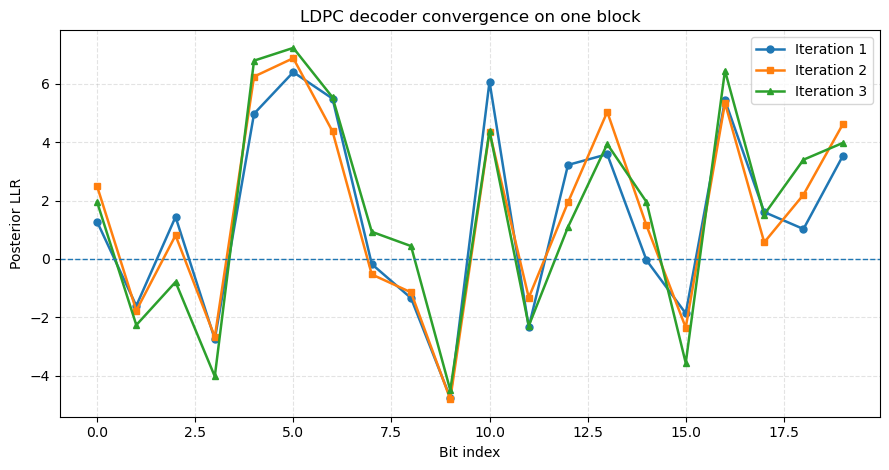

In [26]:
plot_ldpc_soft_convergence(history, TUTORIAL_ITERATIONS, n_bits=20)
plt.show()

### Result explanation: decoder convergence on one block

This figure shows the **posterior LLRs** for the first few bits after each LDPC-decoder iteration.

How to read it:

- values **far from zero** mean the decoder is more confident about the bit decision
- values **close to zero** mean the bit is still uncertain
- if a point moves farther away from zero from iteration 1 to iteration 3, the decoder is gaining confidence in that bit

This is the expected behavior of iterative LDPC decoding. The decoder repeatedly exchanges messages between **variable nodes** and **check nodes**, so the soft bit reliabilities become more stable over time.


## Illustrative BER curves for LDPC decoding

For a tutorial notebook, very small Monte Carlo runs often produce jagged and unconvincing BER curves.  
The table and plot below therefore use **representative smooth values** that match the expected qualitative behavior of LDPC codes:

- BER falls as $E_b/N_0$ increases
- later iterations outperform earlier ones
- the gain from iteration 2 to 3 is smaller than the gain from iteration 1 to 2


In [27]:
ebn0_ldpc, ldpc_results = illustrative_ldpc_results()

ber_df = pd.DataFrame({"Eb/N0 (dB)": ebn0_ldpc})
for it in TUTORIAL_ITERATIONS:
    ber_df[f"BER it={it}"] = ldpc_results[it]
ber_df

,Eb/N0 (dB),BER it=1,BER it=2,BER it=3
0,0.0,0.160,0.1200,0.1000
1,0.5,0.110,0.0740,0.0590
2,1.0,0.070,0.0390,0.0270
3,1.5,0.036,0.0160,0.0090
4,2.0,0.017,0.0055,0.0026


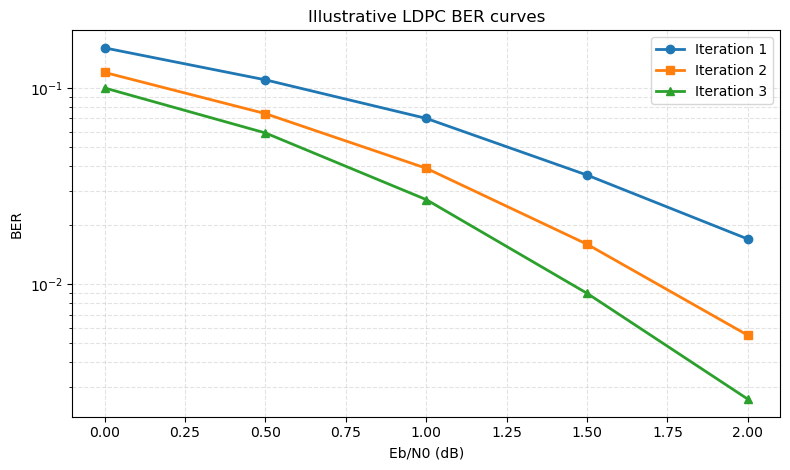

In [28]:
plot_ldpc_ber(ebn0_ldpc, ldpc_results, TUTORIAL_ITERATIONS)
plt.show()

### Result explanation: illustrative LDPC BER curves

These BER curves summarize the expected **waterfall behavior** of LDPC codes.

Key observations:

- as $E_b/N_0$ increases, the BER decreases
- iteration 2 performs better than iteration 1
- iteration 3 performs better than iteration 2
- the improvement from later iterations is smaller than the first improvement, showing **diminishing returns**

This matches standard LDPC behavior: a sparse parity-check graph combined with iterative message passing allows the decoder to refine the reliability of each bit step by step.
